<a href="https://colab.research.google.com/github/armandoordonez/AI-Engineering/blob/main/LLM_paso_a_paso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🧠 Entendiendo los Large Language Models (LLMs) — Paso a Paso

Este notebook explica, de forma **gráfica, práctica y progresiva**, los conceptos fundamentales detrás de los modelos de lenguaje grandes (LLMs) como GPT, Claude, LLaMA, etc.

No usamos frameworks de deep learning "caja negra": todo se implementa con **NumPy puro**, para que puedas ver exactamente qué pasa en cada paso.

## 🗺️ Contenido

1. ¿Qué es un LLM?
2. Tokenización
3. Embeddings y representación semántica
4. Arquitectura Transformer
5. Attention y Self-Attention
6. Entrenamiento: Pretraining
7. Fine-tuning
8. Inference (generación de texto)

> 💡 Ejecuta las celdas en orden (Shift+Enter). Cada sección combina teoría breve + código + visualización.


In [10]:

# 📦 Librerías necesarias (todas estándar del ecosistema científico de Python)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.cm as cm

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente



---
# 1️⃣ ¿Qué es un LLM?

Un **LLM (Large Language Model)** es una red neuronal entrenada con enormes cantidades de texto para aprender a **predecir la siguiente palabra (token)** dado un contexto.

De esa tarea aparentemente simple —"adivinar qué palabra sigue"— emergen capacidades sorprendentes: responder preguntas, programar, traducir, razonar, etc.

**Flujo general de un LLM:**

`Texto` → `Tokenización` → `Embeddings` → `Transformer (Attention + FFN)` → `Probabilidades sobre el vocabulario` → `Texto generado`

Vamos a recorrer cada una de estas etapas con código y visualizaciones.


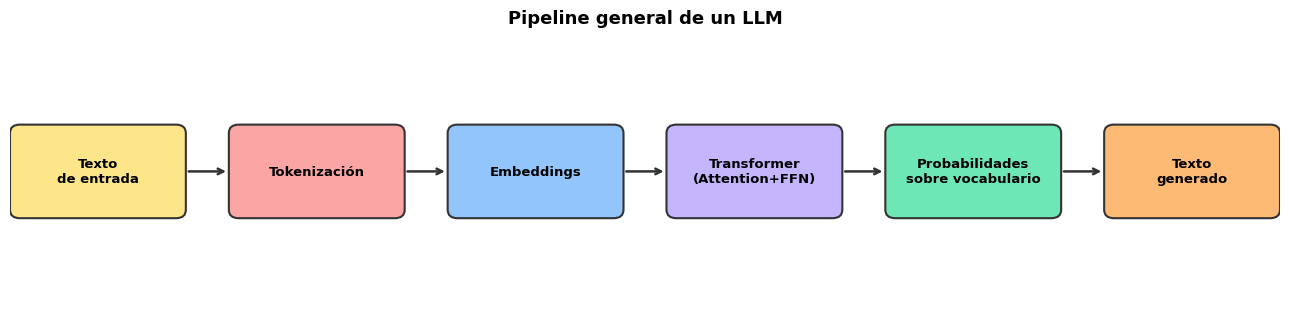

In [11]:

# Diagrama del flujo general de un LLM
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3)
ax.axis('off')

steps = ["Texto\nde entrada", "Tokenización", "Embeddings", "Transformer\n(Attention+FFN)", "Probabilidades\nsobre vocabulario", "Texto\ngenerado"]
colors = ["#FDE68A", "#FCA5A5", "#93C5FD", "#C4B5FD", "#6EE7B7", "#FDBA74"]
x_positions = np.linspace(0.9, 12.1, len(steps))

for i, (x, s, c) in enumerate(zip(x_positions, steps, colors)):
    box = FancyBboxPatch((x-0.85, 1.0), 1.7, 1.0, boxstyle="round,pad=0.05,rounding_size=0.1",
                          linewidth=1.5, edgecolor="#333333", facecolor=c)
    ax.add_patch(box)
    ax.text(x, 1.5, s, ha='center', va='center', fontsize=9.5, weight='bold')
    if i < len(steps)-1:
        ax.annotate('', xy=(x_positions[i+1]-0.9, 1.5), xytext=(x+0.9, 1.5),
                    arrowprops=dict(arrowstyle='->', lw=1.8, color='#333333'))

ax.set_title("Pipeline general de un LLM", fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()



---
# 2️⃣ Concepto de Tokenización

Los modelos no entienden texto crudo, sino **números**. La **tokenización** divide el texto en unidades llamadas *tokens* (palabras, subpalabras o caracteres) y les asigna un ID numérico.

Los LLMs modernos usan tokenización **por subpalabras** (ej. Byte Pair Encoding - BPE), que:
- Reduce el tamaño del vocabulario.
- Maneja palabras desconocidas dividiéndolas en piezas conocidas.
- Es un punto intermedio entre tokenizar por caracteres (vocabulario chico, secuencias largas) y por palabras completas (vocabulario enorme).

Vamos a implementar una versión simplificada de **BPE** para ver el proceso de fusión de pares de caracteres paso a paso.


In [12]:

# --- Implementación simplificada de Byte Pair Encoding (BPE) ---
from collections import Counter

corpus = "el gato juega con el perro y el perro juega con el gato"

def get_stats(tokens_list):
    pairs = Counter()
    for tokens in tokens_list:
        for i in range(len(tokens)-1):
            pairs[(tokens[i], tokens[i+1])] += 1
    return pairs

def merge_pair(tokens_list, pair):
    merged = "".join(pair)
    new_list = []
    for tokens in tokens_list:
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens)-1 and (tokens[i], tokens[i+1]) == pair:
                new_tokens.append(merged)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        new_list.append(new_tokens)
    return new_list

# Empezamos a nivel de caracter, con </w> marcando fin de palabra
words = corpus.split(" ")
tokens_list = [list(w) + ["</w>"] for w in words]

print("Estado inicial (tokenización por caracteres):")
print(tokens_list[0], "...")

n_merges = 6
history = [ [t[:] for t in tokens_list] ]
merges_done = []
for step in range(n_merges):
    pairs = get_stats(tokens_list)
    if not pairs:
        break
    best_pair = pairs.most_common(1)[0][0]
    tokens_list = merge_pair(tokens_list, best_pair)
    merges_done.append((best_pair, pairs[best_pair]))
    history.append([t[:] for t in tokens_list])

for i, (pair, freq) in enumerate(merges_done, 1):
    print(f"Fusión {i}: {pair[0]!r} + {pair[1]!r} -> {''.join(pair)!r}  (frecuencia={freq})")


Estado inicial (tokenización por caracteres):
['e', 'l', '</w>'] ...
Fusión 1: 'e' + 'l' -> 'el'  (frecuencia=4)
Fusión 2: 'el' + '</w>' -> 'el</w>'  (frecuencia=4)
Fusión 3: 'g' + 'a' -> 'ga'  (frecuencia=4)
Fusión 4: 'o' + '</w>' -> 'o</w>'  (frecuencia=4)
Fusión 5: 'ga' + 't' -> 'gat'  (frecuencia=2)
Fusión 6: 'gat' + 'o</w>' -> 'gato</w>'  (frecuencia=2)


/tmp/ipykernel_692/1265733292.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


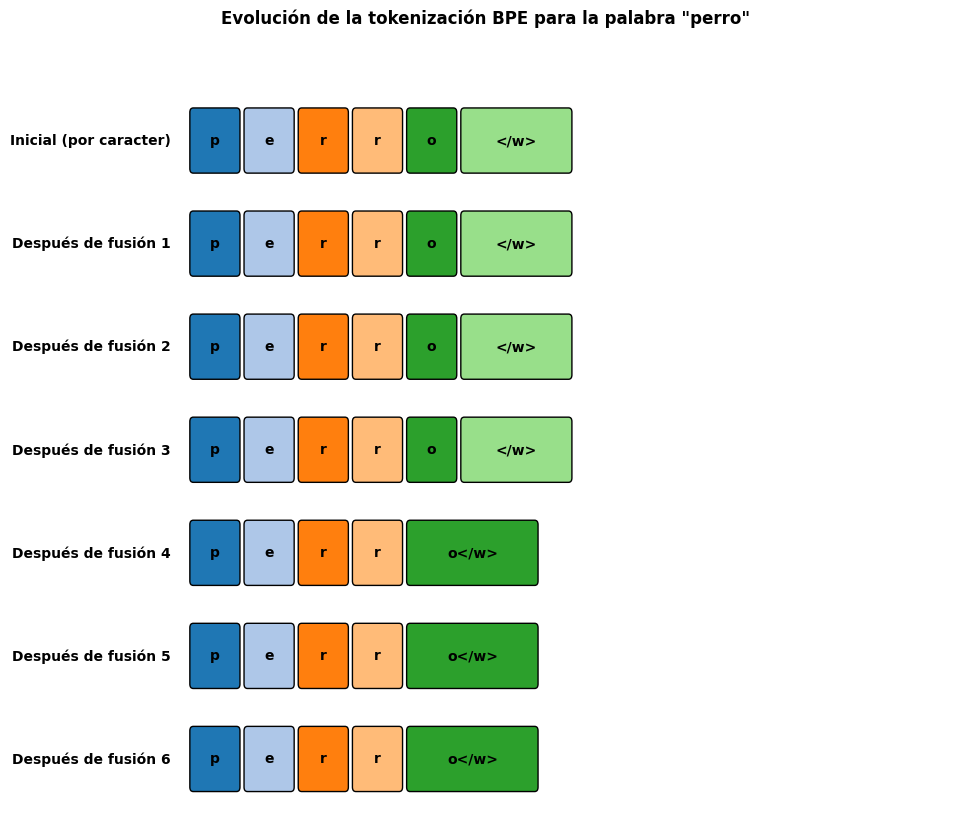


👉 Los tokenizadores reales (ej. GPT, Claude) aplican esta misma idea de fusión de pares,
   pero entrenados sobre miles de millones de palabras y con vocabularios de ~50k-100k tokens.


In [14]:
# Visualización: cómo va cambiando la tokenización de la palabra "perro" en cada fusión
target_word_idx = words.index("perro")

fig, axes = plt.subplots(len(history), 1, figsize=(10, 1.1*len(history)))
cmap = cm.get_cmap('tab20')

for step, tokens_snapshot in enumerate(history):
    ax = axes[step]
    ax.set_xlim(-1, 12) # Adjusted x-axis limit for better spacing
    ax.set_ylim(0, 1)
    ax.axis('off')
    toks = tokens_snapshot[target_word_idx]
    x = 0.5 # Adjusted starting x position
    for j, t in enumerate(toks):
        w = 0.4 + 0.3*len(t) # Adjusted token box width
        color = cmap(j % 20)
        ax.add_patch(mpatches.FancyBboxPatch((x, 0.15), w, 0.7, boxstyle="round,pad=0.02,rounding_size=0.05",
                                              facecolor=color, edgecolor='black', linewidth=1))
        ax.text(x + w/2, 0.5, t, ha='center', va='center', fontsize=10, weight='bold')
        x += w + 0.1 # Adjusted spacing between boxes
    label = "Inicial (por caracter)" if step == 0 else f"Después de fusión {step}"
    ax.text(0.2, 0.5, label, ha='right', va='center', fontsize=10, weight='bold') # Adjusted label position and style

fig.suptitle('Evolución de la tokenización BPE para la palabra "perro"', fontsize=12, weight='bold', y=1.05) # Adjusted suptitle y position
plt.tight_layout()
plt.show()

print("\n👉 Los tokenizadores reales (ej. GPT, Claude) aplican esta misma idea de fusión de pares,")
print("   pero entrenados sobre miles de millones de palabras y con vocabularios de ~50k-100k tokens.")



**Idea clave:** cuantas más veces aparece junto un par de símbolos, más probable es que se fusionen en un solo token. Así el vocabulario final mezcla palabras completas frecuentes ("el", "de") con fragmentos de palabras raras.



---
# 3️⃣ Embeddings y Representación Semántica

Un **embedding** es un vector numérico (de decenas o miles de dimensiones) que representa el *significado* de un token. Palabras con significados similares tienen vectores **cercanos** en ese espacio.

La propiedad más famosa de los embeddings es que capturan relaciones semánticas de forma algebraica:

`rey - hombre + mujer ≈ reina`

Vamos a construir embeddings de juguete (2D, a mano) para ilustrar esta idea de forma visual, y luego ver cómo se mide la similitud con **similitud coseno**.


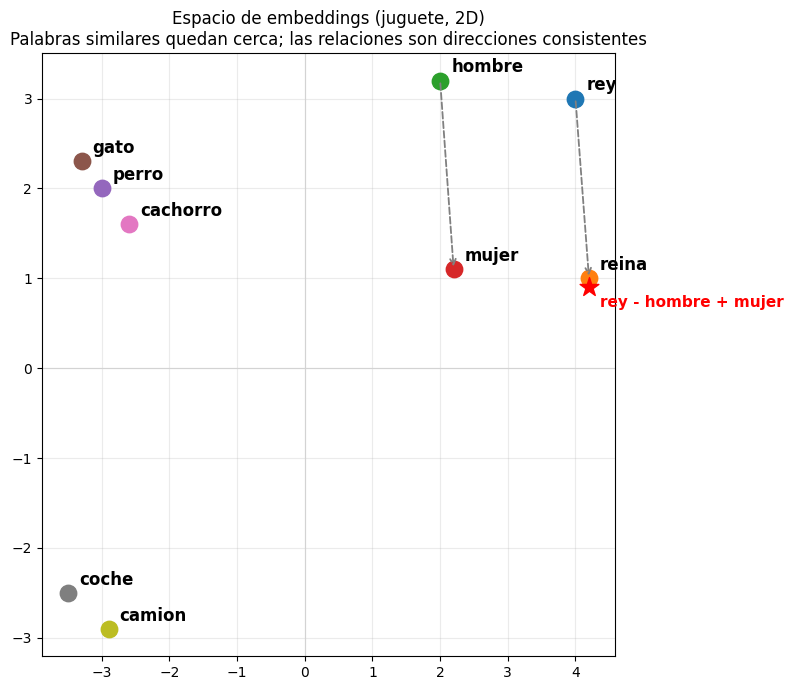

Distancia entre 'rey - hombre + mujer' y 'reina' real: 0.10 (cuanto más chica, mejor captura la analogía)


In [ ]:

# Embeddings de juguete construidos a mano para que las relaciones sean visibles en 2D
palabras_emb = {
    "rey":     np.array([4.0, 3.0]),
    "reina":   np.array([4.2, 1.0]),
    "hombre":  np.array([2.0, 3.2]),
    "mujer":   np.array([2.2, 1.1]),
    "perro":   np.array([-3.0, 2.0]),
    "gato":    np.array([-3.3, 2.3]),
    "cachorro":np.array([-2.6, 1.6]),
    "coche":   np.array([-3.5, -2.5]),
    "camion":  np.array([-2.9, -2.9]),
}

fig, ax = plt.subplots(figsize=(8, 7))
for palabra, v in palabras_emb.items():
    ax.scatter(*v, s=140, zorder=3)
    ax.annotate(palabra, v, textcoords="offset points", xytext=(8,6), fontsize=12, weight='bold')

# Vector de analogía: rey - hombre + mujer
analogia = palabras_emb["rey"] - palabras_emb["hombre"] + palabras_emb["mujer"]
ax.scatter(*analogia, s=200, marker='*', color='red', zorder=4)
ax.annotate("rey - hombre + mujer", analogia, textcoords="offset points", xytext=(8,-14),
            fontsize=11, color='red', weight='bold')

ax.annotate('', xy=palabras_emb["mujer"], xytext=palabras_emb["hombre"],
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.3, linestyle='dashed'))
ax.annotate('', xy=palabras_emb["reina"], xytext=palabras_emb["rey"],
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.3, linestyle='dashed'))

ax.set_title("Espacio de embeddings (juguete, 2D)\nPalabras similares quedan cerca; las relaciones son direcciones consistentes", fontsize=12)
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

dist = np.linalg.norm(analogia - palabras_emb["reina"])
print(f"Distancia entre 'rey - hombre + mujer' y 'reina' real: {dist:.2f} (cuanto más chica, mejor captura la analogía)")


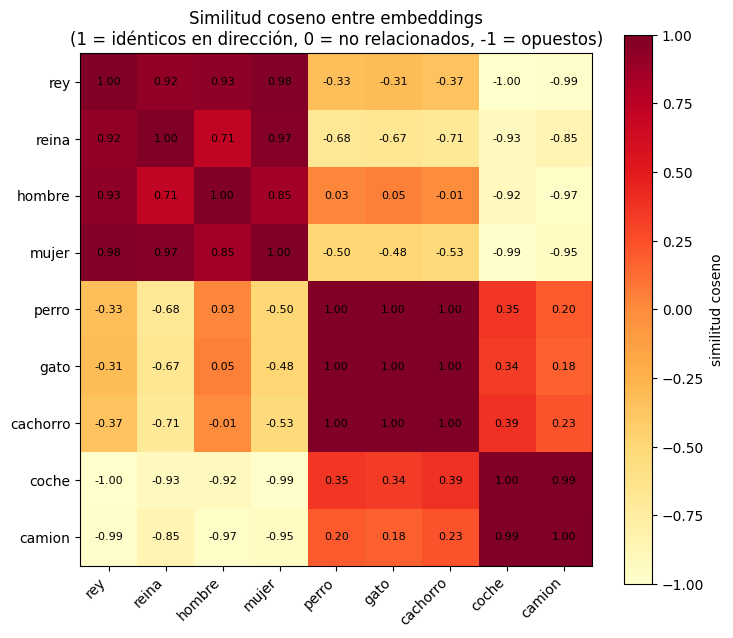

👉 Nota cómo 'perro', 'gato' y 'cachorro' tienen alta similitud entre sí, y baja con 'coche'/'camion'.


In [ ]:

# Similitud coseno entre embeddings: mide el ANGULO entre vectores, no la distancia absoluta
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

nombres = list(palabras_emb.keys())
n = len(nombres)
sim_matrix = np.zeros((n, n))
for i, a in enumerate(nombres):
    for j, b in enumerate(nombres):
        sim_matrix[i, j] = cos_sim(palabras_emb[a], palabras_emb[b])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(nombres)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center', fontsize=8)
ax.set_title("Similitud coseno entre embeddings\n(1 = idénticos en dirección, 0 = no relacionados, -1 = opuestos)")
plt.colorbar(im, label="similitud coseno")
plt.tight_layout()
plt.show()

print("👉 Nota cómo 'perro', 'gato' y 'cachorro' tienen alta similitud entre sí, y baja con 'coche'/'camion'.")



En un LLM real, estos embeddings tienen cientos o miles de dimensiones y **se aprenden durante el entrenamiento** (no se definen a mano como aquí). Cada token del vocabulario tiene su propio vector, guardado en una gran tabla llamada *embedding matrix*.



---
# 4️⃣ Arquitectura Transformer

El **Transformer** (Vaswani et al., 2017) es la arquitectura detrás de los LLMs modernos. Su componente clave es el mecanismo de **atención**, que permite que cada token "mire" a otros tokens de la secuencia para decidir qué información es relevante.

Un bloque Transformer (estilo decoder, usado por GPT/Claude) se compone de:

1. **Embeddings + Positional Encoding**: convierte tokens en vectores y les añade información de *posición* (el Transformer no procesa la secuencia en orden, así que necesita saber "dónde" está cada token).
2. **Multi-Head Self-Attention**: cada token calcula cuánta atención prestarle a los demás.
3. **Add & Norm**: conexión residual + normalización (estabiliza el entrenamiento).
4. **Feed-Forward Network (FFN)**: una pequeña red densa aplicada a cada posición.
5. Estos bloques se **apilan N veces** (GPT-3 tiene 96 capas, por ejemplo).


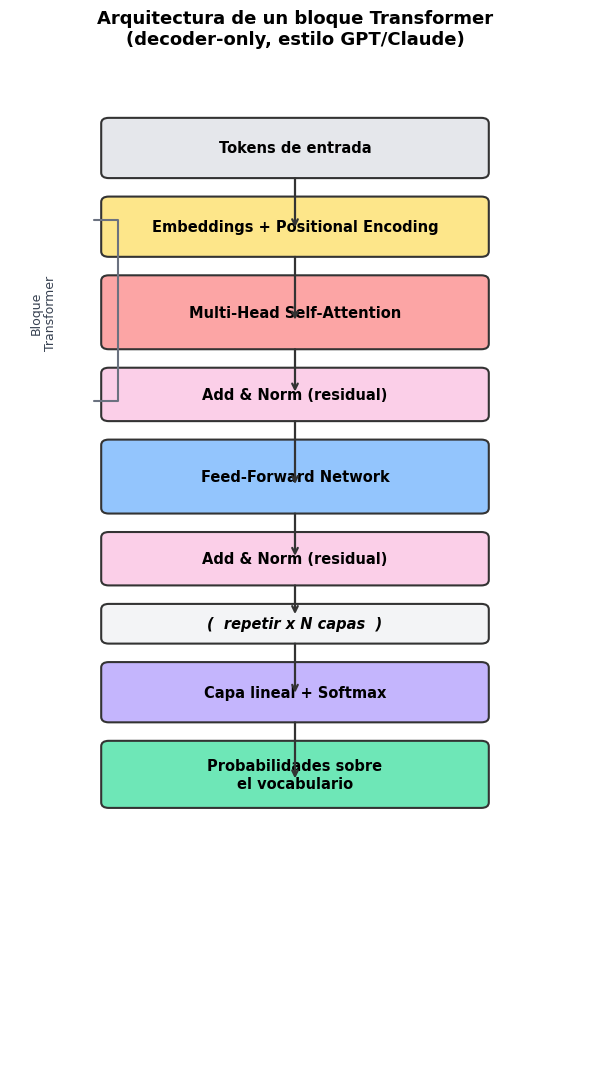

In [ ]:

# Diagrama de un bloque Transformer (decoder-only, estilo GPT)
fig, ax = plt.subplots(figsize=(6, 11))
ax.set_xlim(0, 6)
ax.set_ylim(0, 15)
ax.axis('off')

blocks = [
    ("Tokens de entrada", "#E5E7EB", 0.8),
    ("Embeddings + Positional Encoding", "#FDE68A", 0.8),
    ("Multi-Head Self-Attention", "#FCA5A5", 1.0),
    ("Add & Norm (residual)", "#FBCFE8", 0.7),
    ("Feed-Forward Network", "#93C5FD", 1.0),
    ("Add & Norm (residual)", "#FBCFE8", 0.7),
    ("(  repetir x N capas  )", "#F3F4F6", 0.5),
    ("Capa lineal + Softmax", "#C4B5FD", 0.8),
    ("Probabilidades sobre\nel vocabulario", "#6EE7B7", 0.9),
]

y = 14.0
centers = []
for name, color, h in blocks:
    box = FancyBboxPatch((1, y-h), 4, h, boxstyle="round,pad=0.04,rounding_size=0.08",
                          linewidth=1.5, edgecolor="#333333", facecolor=color)
    ax.add_patch(box)
    style = 'italic' if name.startswith("(") else 'normal'
    ax.text(3, y-h/2, name, ha='center', va='center', fontsize=10.5, weight='bold', style=style)
    centers.append((3, y-h))
    y -= h + 0.35

for i in range(len(centers)-1):
    x0, y0 = centers[i]
    x1, y1 = centers[i+1]
    top_of_next = y1 + (14.0 if i==0 else 0)  # not used, simple arrow below
    ax.annotate('', xy=(3, y1+0.35), xytext=(3, y0),
                arrowprops=dict(arrowstyle='->', lw=1.6, color='#333333'))

# Bracket indicating the repeated block (attention + FFN)
ax.annotate('', xy=(0.85, 9.9), xytext=(0.85, 12.55),
            arrowprops=dict(arrowstyle='-', lw=1.5, color='#6B7280',
                             connectionstyle="bar,fraction=-0.15"))
ax.text(0.35, 11.2, "Bloque\nTransformer", ha='center', va='center', fontsize=9, color='#374151', rotation=90)

ax.set_title("Arquitectura de un bloque Transformer\n(decoder-only, estilo GPT/Claude)", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()



**¿Por qué "Add & Norm" (conexiones residuales)?** Permiten que la información original "salte" cada subcapa y se sume a la salida transformada. Esto evita que la señal se degrade al apilar muchas capas, y es clave para poder entrenar redes muy profundas (decenas o cientos de capas).



---
# 5️⃣ Attention y Self-Attention

La **self-attention** permite que cada token de una secuencia calcule una representación que combina información de **todos los demás tokens**, ponderada por qué tan relevantes son entre sí.

### Los 3 vectores clave

Para cada token se calculan tres vectores (multiplicando su embedding por matrices aprendidas):

- **Q (Query)**: "¿qué estoy buscando?"
- **K (Key)**: "¿qué tengo para ofrecer?"
- **V (Value)**: "¿qué información entrego si me prestan atención?"

### La fórmula

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

1. `Q·Kᵀ` mide qué tan compatible es cada query con cada key (similitud).
2. Se divide por `√d_k` para estabilizar los gradientes.
3. `softmax` convierte esos puntajes en pesos que suman 1 (una distribución de probabilidad).
4. Se usa esa distribución para hacer un **promedio ponderado** de los vectores `V`.

Vamos a implementarlo desde cero con NumPy sobre una oración de ejemplo.


In [15]:

# --- Self-Attention desde cero con NumPy ---
oracion = ["El", "gato", "persigue", "al", "raton"]
d_model = 8  # dimension de los embeddings (juguete)
n = len(oracion)

np.random.seed(7)
X = np.random.randn(n, d_model) * 0.6   # embeddings de entrada (simulados)

# Matrices de proyección aprendidas (aquí, aleatorias para la demo)
W_Q = np.random.randn(d_model, d_model) * 0.4
W_K = np.random.randn(d_model, d_model) * 0.4
W_V = np.random.randn(d_model, d_model) * 0.4

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

scores = Q @ K.T / np.sqrt(d_model)     # (n, n) compatibilidad entre cada par de tokens
attn_weights = softmax(scores, axis=-1)  # cada fila suma 1
output = attn_weights @ V                # promedio ponderado de V

print("Matriz de pesos de atención (filas = token que 'pregunta', columnas = token 'consultado'):\n")
print(np.round(attn_weights, 2))
print("\nCada fila suma 1.0 ->", np.round(attn_weights.sum(axis=1), 3))


Matriz de pesos de atención (filas = token que 'pregunta', columnas = token 'consultado'):

[[0.14 0.18 0.22 0.2  0.26]
 [0.17 0.13 0.27 0.26 0.16]
 [0.26 0.19 0.14 0.14 0.27]
 [0.22 0.21 0.19 0.18 0.2 ]
 [0.24 0.23 0.25 0.2  0.07]]

Cada fila suma 1.0 -> [1. 1. 1. 1. 1.]


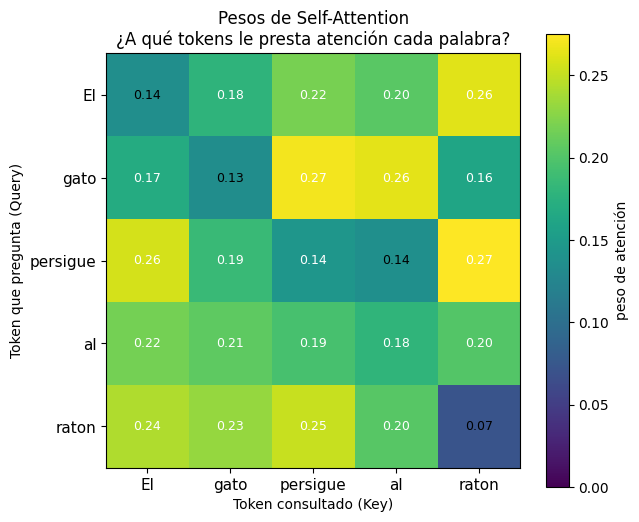

👉 Ejemplo: al procesar 'persigue', el modelo distribuye su atención así:
   El         -> 25.74%
   gato       -> 18.58%
   persigue   -> 14.45%
   al         -> 13.73%
   raton      -> 27.49%


In [16]:

# Visualización: heatmap de atención
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(attn_weights, cmap='viridis', vmin=0, vmax=attn_weights.max())
ax.set_xticks(range(n)); ax.set_xticklabels(oracion, fontsize=11)
ax.set_yticks(range(n)); ax.set_yticklabels(oracion, fontsize=11)
ax.set_xlabel("Token consultado (Key)")
ax.set_ylabel("Token que pregunta (Query)")
for i in range(n):
    for j in range(n):
        color = 'white' if attn_weights[i,j] > attn_weights.max()*0.5 else 'black'
        ax.text(j, i, f"{attn_weights[i,j]:.2f}", ha='center', va='center', fontsize=9, color=color)
ax.set_title("Pesos de Self-Attention\n¿A qué tokens le presta atención cada palabra?", fontsize=12)
plt.colorbar(im, label="peso de atención")
plt.tight_layout()
plt.show()

fila = 2  # "persigue"
print(f"👉 Ejemplo: al procesar '{oracion[fila]}', el modelo distribuye su atención así:")
for tok, w in zip(oracion, attn_weights[fila]):
    print(f"   {tok:10s} -> {w:.2%}")



### 🔀 ¿Y el "Self" y el "Multi-Head"?

- **Self-Attention**: Q, K y V provienen de la *misma* secuencia (cada token se compara con los demás tokens de la misma oración). Contrasta con la "cross-attention" usada en traducción, donde Q viene de una secuencia y K,V de otra.
- **Multi-Head Attention**: en vez de calcular una sola atención, se calculan **varias en paralelo** ("cabezas"), cada una con sus propias matrices W_Q, W_K, W_V. Esto permite capturar distintos tipos de relaciones simultáneamente (ej. una cabeza puede enfocarse en relaciones sintácticas, otra en relaciones semánticas). Los resultados de todas las cabezas se concatenan y se combinan con una capa lineal final.


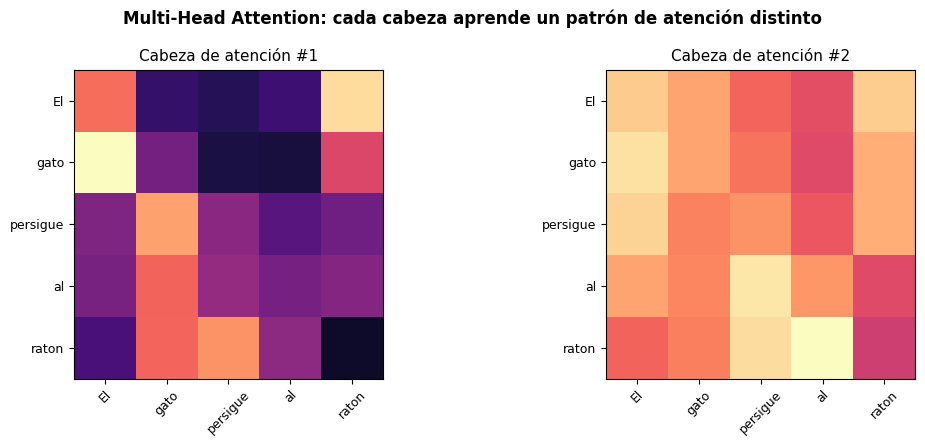

👉 Nota cómo cada cabeza produce un patrón de atención diferente sobre la misma oración.


In [ ]:

# Demo simplificada de Multi-Head Attention (2 cabezas) sobre la misma oración
n_heads = 2
d_head = d_model // n_heads

fig, axes = plt.subplots(1, n_heads, figsize=(11, 4.5))
np.random.seed(3)
for h in range(n_heads):
    Wq_h = np.random.randn(d_model, d_head) * 0.4
    Wk_h = np.random.randn(d_model, d_head) * 0.4
    Wv_h = np.random.randn(d_model, d_head) * 0.4
    Qh, Kh, Vh = X @ Wq_h, X @ Wk_h, X @ Wv_h
    scores_h = Qh @ Kh.T / np.sqrt(d_head)
    w_h = softmax(scores_h, axis=-1)

    ax = axes[h]
    im = ax.imshow(w_h, cmap='magma', vmin=0, vmax=w_h.max())
    ax.set_xticks(range(n)); ax.set_xticklabels(oracion, rotation=45, fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(oracion, fontsize=9)
    ax.set_title(f"Cabeza de atención #{h+1}", fontsize=11)

fig.suptitle("Multi-Head Attention: cada cabeza aprende un patrón de atención distinto", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()
print("👉 Nota cómo cada cabeza produce un patrón de atención diferente sobre la misma oración.")



---
# 6️⃣ Entrenamiento: Pretraining

El **pretraining** es la primera y más costosa etapa de entrenamiento. El modelo aprende de **texto masivo y sin etiquetar** (libros, webs, código, etc.) con un objetivo simple pero poderoso:

> **Predecir el siguiente token dado el contexto anterior** (*next-token prediction*).

Para cada posición en el texto, el modelo:
1. Predice una distribución de probabilidad sobre todo el vocabulario.
2. Se compara con el token real usando una función de pérdida (**cross-entropy**).
3. Se ajustan los pesos del modelo (millones o miles de millones de parámetros) vía **descenso de gradiente** para reducir el error.

Este proceso se repite miles de millones de veces sobre trillones de tokens. Vamos a simularlo a pequeña escala con un modelo de lenguaje **bigrama** (predice la siguiente palabra mirando solo la anterior) entrenado con descenso de gradiente real.


In [ ]:

# --- Mini "pretraining" real con un modelo bigrama (softmax lineal) ---
texto = "el gato come pescado el perro come carne el gato duerme el perro corre el gato juega el perro juega"
palabras = texto.split()
vocab = sorted(set(palabras))
word2id = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print(f"Vocabulario ({V} palabras): {vocab}")

# Pares (palabra_actual -> siguiente_palabra) como datos de entrenamiento
pares = [(word2id[palabras[i]], word2id[palabras[i+1]]) for i in range(len(palabras)-1)]

# Modelo: una matriz de pesos W (V x V). logits = one_hot(actual) @ W
np.random.seed(1)
W = np.random.randn(V, V) * 0.01

def forward(idx):
    logits = W[idx]              # fila correspondiente a la palabra actual
    probs = softmax(logits)
    return probs

lr = 0.5
epochs = 300
losses = []
for ep in range(epochs):
    total_loss = 0
    grads = np.zeros_like(W)
    for cur, nxt in pares:
        probs = forward(cur)
        loss = -np.log(probs[nxt] + 1e-9)
        total_loss += loss
        # gradiente de cross-entropy + softmax respecto a logits
        d_logits = probs.copy()
        d_logits[nxt] -= 1
        grads[cur] += d_logits
    W -= lr * grads / len(pares)
    losses.append(total_loss / len(pares))

print(f"\nPérdida inicial: {losses[0]:.3f}  ->  Pérdida final: {losses[-1]:.3f}")


Vocabulario (9 palabras): ['carne', 'come', 'corre', 'duerme', 'el', 'gato', 'juega', 'perro', 'pescado']

Pérdida inicial: 2.197  ->  Pérdida final: 0.742


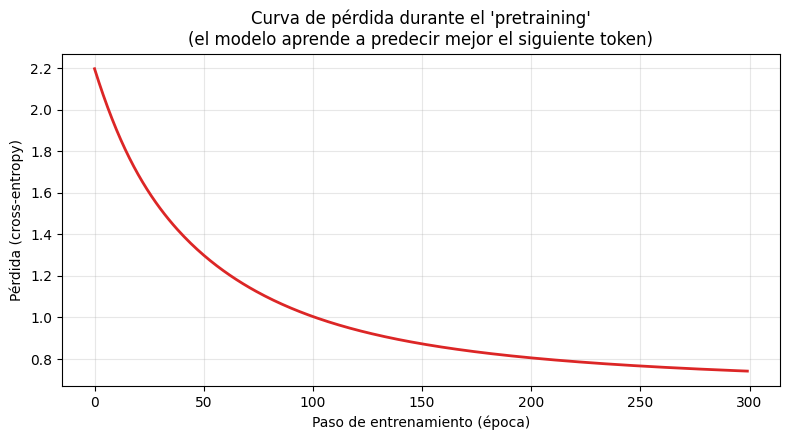

Predicciones del modelo YA ENTRENADO (top-3 palabra siguiente más probable):

  después de 'el':  perro (48%), gato (48%), corre (1%)
  después de 'gato':  come (30%), duerme (30%), juega (30%)
  después de 'perro':  come (30%), corre (30%), juega (30%)
  después de 'come':  carne (44%), pescado (44%), come (2%)


In [ ]:

# Visualizar la curva de pérdida (loss) durante el pretraining
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(losses, color='#DC2626', lw=2)
ax.set_xlabel("Paso de entrenamiento (época)")
ax.set_ylabel("Pérdida (cross-entropy)")
ax.set_title("Curva de pérdida durante el 'pretraining'\n(el modelo aprende a predecir mejor el siguiente token)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Predicciones del modelo YA ENTRENADO (top-3 palabra siguiente más probable):\n")
for w in ["el", "gato", "perro", "come"]:
    probs = forward(word2id[w])
    top3 = np.argsort(probs)[::-1][:3]
    preds = ", ".join(f"{vocab[i]} ({probs[i]:.0%})" for i in top3)
    print(f"  después de '{w}':  {preds}")



👉 Con solo esta frase de entrenamiento, el modelo ya "aprendió" patrones como que después de **"el"** suele venir **"gato"** o **"perro"**, y que después de **"come"** suele venir un alimento. Un LLM real hace exactamente esto, pero con una arquitectura Transformer completa (no un simple bigrama) y **billones** de ejemplos.



---
# 7️⃣ Fine-tuning

Después del pretraining, el modelo "sabe mucho" sobre el lenguaje en general, pero no sabe **seguir instrucciones** ni comportarse como un asistente. El **fine-tuning** ajusta un modelo ya preentrenado usando un dataset **más pequeño y específico**, típicamente con:

- **Instruction tuning**: pares (instrucción → respuesta deseada) para que el modelo aprenda a ser útil y seguir órdenes.
- **RLHF / preferencias**: ajustar el modelo según qué respuestas prefieren humanos.
- **Fine-tuning de dominio**: especializarlo en medicina, leyes, código, etc.

### Diferencias clave con el pretraining

| | Pretraining | Fine-tuning |
|---|---|---|
| Datos | Masivos, generales, sin etiquetar | Pequeños, específicos, curados |
| Objetivo | Predecir el siguiente token (general) | Adaptar el comportamiento a una tarea |
| Costo | Muy alto (semanas, miles de GPUs) | Mucho menor (horas/días) |
| Punto de partida | Pesos aleatorios | Pesos ya preentrenados |
| Learning rate | Más alto | Más bajo (ajuste fino, no reaprender todo) |

Vamos a simular esto: partimos del modelo bigrama ya preentrenado y lo re-entrenamos (fine-tuning) con un dataset chico y específico, con un learning rate más bajo.


In [ ]:

# --- Simulación de Fine-tuning: partimos del modelo pre-entrenado (W) ---
import copy
W_pretrained = copy.deepcopy(W)   # guardamos una copia del modelo "base"
W_finetuned = copy.deepcopy(W)    # este lo vamos a ajustar

# Dataset de fine-tuning: pequeño y específico (el gato SIEMPRE duerme, no come ni juega)
texto_ft = "el gato duerme el gato duerme el gato duerme el gato duerme"
palabras_ft = texto_ft.split()
pares_ft = [(word2id[palabras_ft[i]], word2id[palabras_ft[i+1]]) for i in range(len(palabras_ft)-1)]

lr_ft = 0.15       # learning rate MENOR que en pretraining (ajuste fino, no reaprender desde cero)
epochs_ft = 80
losses_ft = []
for ep in range(epochs_ft):
    total_loss = 0
    grads = np.zeros_like(W_finetuned)
    for cur, nxt in pares_ft:
        probs = softmax(W_finetuned[cur])
        loss = -np.log(probs[nxt] + 1e-9)
        total_loss += loss
        d_logits = probs.copy()
        d_logits[nxt] -= 1
        grads[cur] += d_logits
    W_finetuned -= lr_ft * grads / len(pares_ft)
    losses_ft.append(total_loss / len(pares_ft))

print("Fine-tuning completado.\n")
print("Comparación de predicciones ANTES vs DESPUES del fine-tuning para 'gato':\n")
for nombre, Wm in [("Pretrained (base)", W_pretrained), ("Fine-tuned", W_finetuned)]:
    probs = softmax(Wm[word2id["gato"]])
    top3 = np.argsort(probs)[::-1][:3]
    preds = ", ".join(f"{vocab[i]} ({probs[i]:.0%})" for i in top3)
    print(f"  {nombre:18s} -> después de 'gato':  {preds}")


Fine-tuning completado.

Comparación de predicciones ANTES vs DESPUES del fine-tuning para 'gato':

  Pretrained (base)  -> después de 'gato':  come (30%), duerme (30%), juega (30%)
  Fine-tuned         -> después de 'gato':  duerme (80%), come (8%), juega (8%)


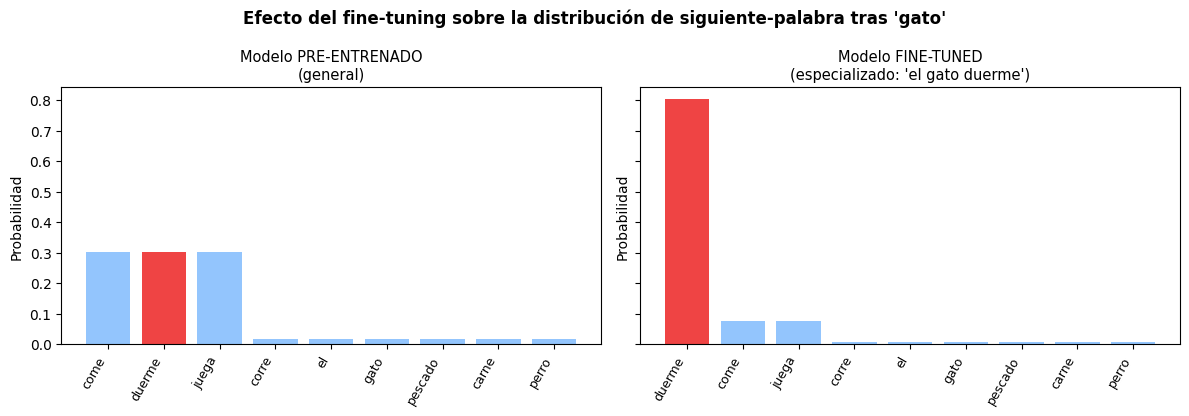

👉 El fine-tuning NO reentrena el modelo desde cero: parte de los pesos preentrenados
   y los ajusta suavemente (lr más bajo, pocos pasos) para sesgar su comportamiento
   hacia el nuevo dataset, sin olvidar todo lo aprendido antes.


In [ ]:

# Visualización comparativa: distribución de probabilidad antes/después del fine-tuning
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, (nombre, Wm) in zip(axes, [("Modelo PRE-ENTRENADO\n(general)", W_pretrained),
                                    ("Modelo FINE-TUNED\n(especializado: 'el gato duerme')", W_finetuned)]):
    probs = softmax(Wm[word2id["gato"]])
    order = np.argsort(probs)[::-1]
    colors = ['#EF4444' if vocab[i]=='duerme' else '#93C5FD' for i in order]
    ax.bar(range(V), probs[order], color=colors)
    ax.set_xticks(range(V)); ax.set_xticklabels([vocab[i] for i in order], rotation=60, ha='right', fontsize=9)
    ax.set_title(nombre, fontsize=10.5)
    ax.set_ylabel("Probabilidad")
plt.suptitle("Efecto del fine-tuning sobre la distribución de siguiente-palabra tras 'gato'", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

print("👉 El fine-tuning NO reentrena el modelo desde cero: parte de los pesos preentrenados")
print("   y los ajusta suavemente (lr más bajo, pocos pasos) para sesgar su comportamiento")
print("   hacia el nuevo dataset, sin olvidar todo lo aprendido antes.")



---
# 8️⃣ Inference (generación de texto)

La **inferencia** es el momento en que *usamos* el modelo ya entrenado para generar texto, token por token:

1. El modelo recibe el contexto (prompt) y produce una distribución de probabilidad sobre el vocabulario para el siguiente token.
2. Se elige un token según una **estrategia de muestreo (sampling)**.
3. Ese token se añade al contexto y se repite el proceso (**autoregresión**).

### Estrategias de muestreo comunes

- **Greedy**: siempre elige el token más probable → determinista, pero puede ser repetitivo/aburrido.
- **Temperature**: escala los logits antes del softmax. Temperatura baja (<1) = más conservador y determinista; alta (>1) = más creativo/aleatorio.
- **Top-k**: solo considera los *k* tokens más probables y muestrea entre ellos.

Vamos a generar texto con nuestro modelo entrenado usando distintas estrategias.


In [ ]:

# --- Generación de texto (inferencia) con distintas estrategias ---
def generar(W_model, palabra_inicial, pasos=8, estrategia="greedy", temperature=1.0, top_k=3, seed=0):
    rng = np.random.default_rng(seed)
    actual = word2id[palabra_inicial]
    salida = [palabra_inicial]
    for _ in range(pasos):
        logits = W_model[actual]
        if estrategia == "greedy":
            nxt = np.argmax(logits)
        elif estrategia == "temperature":
            probs = softmax(logits / temperature)
            nxt = rng.choice(V, p=probs)
        elif estrategia == "top_k":
            probs = softmax(logits)
            top_idx = np.argsort(probs)[::-1][:top_k]
            top_probs = probs[top_idx] / probs[top_idx].sum()
            nxt = rng.choice(top_idx, p=top_probs)
        salida.append(vocab[nxt])
        actual = nxt
    return " ".join(salida)

print("Estrategia GREEDY (siempre el token más probable, determinista):")
print("  ->", generar(W_finetuned, "el", estrategia="greedy"))

print("\nEstrategia TEMPERATURE=0.3 (conservadora):")
for i in range(3):
    print("  ->", generar(W_finetuned, "el", estrategia="temperature", temperature=0.3, seed=i))

print("\nEstrategia TEMPERATURE=1.5 (más aleatoria/creativa):")
for i in range(3):
    print("  ->", generar(W_finetuned, "el", estrategia="temperature", temperature=1.5, seed=i))

print("\nEstrategia TOP-K=3:")
for i in range(3):
    print("  ->", generar(W_finetuned, "el", estrategia="top_k", top_k=3, seed=i))


Estrategia GREEDY (siempre el token más probable, determinista):
  -> el gato duerme el gato duerme el gato duerme

Estrategia TEMPERATURE=0.3 (conservadora):
  -> el gato duerme el gato duerme el gato duerme
  -> el gato duerme el gato duerme el gato duerme
  -> el gato duerme el gato duerme el gato duerme

Estrategia TEMPERATURE=1.5 (más aleatoria/creativa):
  -> el gato duerme come carne gato juega el gato
  -> el gato perro come pescado el gato juega el
  -> el gato duerme el gato duerme el gato come

Estrategia TOP-K=3:
  -> el gato duerme el gato duerme el gato duerme
  -> el gato juega el perro come carne el gato
  -> el gato duerme el gato duerme el gato duerme


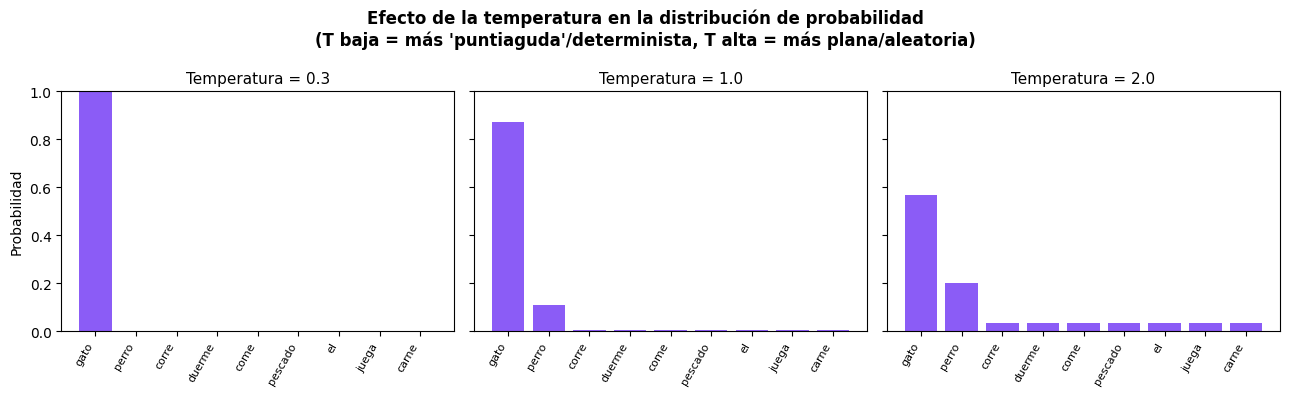

In [ ]:

# Visualización: cómo cambia la distribución de probabilidad con la temperatura
logits_ejemplo = W_finetuned[word2id["el"]]
temperaturas = [0.3, 1.0, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, T in zip(axes, temperaturas):
    probs = softmax(logits_ejemplo / T)
    order = np.argsort(probs)[::-1]
    ax.bar(range(V), probs[order], color='#8B5CF6')
    ax.set_xticks(range(V)); ax.set_xticklabels([vocab[i] for i in order], rotation=60, ha='right', fontsize=8)
    ax.set_title(f"Temperatura = {T}", fontsize=11)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("Probabilidad")
fig.suptitle("Efecto de la temperatura en la distribución de probabilidad\n(T baja = más 'puntiaguda'/determinista, T alta = más plana/aleatoria)",
             fontsize=12, weight='bold')
plt.tight_layout()
plt.show()



👉 **Temperatura baja** concentra la probabilidad en pocos candidatos (salidas más predecibles y "seguras"). **Temperatura alta** aplana la distribución, dando más chance a tokens menos probables (salidas más variadas, pero con riesgo de ser menos coherentes).

Esto es exactamente el parámetro `temperature` que ves en las APIs de LLMs (incluida la de Claude).



---
# 🎯 Resumen

| Concepto | Idea clave |
|---|---|
| **LLM** | Red neuronal entrenada para predecir el siguiente token |
| **Tokenización** | Divide texto en unidades (subpalabras) con IDs numéricos |
| **Embeddings** | Vectores que capturan el significado; similares → cercanos |
| **Transformer** | Arquitectura que apila bloques de atención + FFN |
| **Attention** | Cada token pondera la relevancia de los demás tokens |
| **Pretraining** | Aprender de texto masivo prediciendo el siguiente token |
| **Fine-tuning** | Ajuste fino sobre datos específicos, partiendo del modelo preentrenado |
| **Inference** | Generar texto token a token, con estrategias de muestreo |

